In [1]:
!pip install -q kaggle lightgbm xgboost catboost shap

# upload your kaggle.json API token (from kaggle.com/settings)
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d shivamb/machine-predictive-maintenance-classification -p /content/data --unzip
!ls /content/data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


Saving predictive_maintenance.csv to predictive_maintenance.csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification
License(s): CC0-1.0
100% 137k/137k [00:00<00:00, 619kB/s]

predictive_maintenance.csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/data/predictive_maintenance.csv")
print(df.shape)
df.head()

(10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [3]:
df = df.drop(columns=["UDI", "Product ID"])
df.columns.tolist()

['Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Target',
 'Failure Type']

In [4]:
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64
Duplicate rows: 0


In [5]:
num_cols = ["Air temperature [K]", "Process temperature [K]",
            "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

is_outlier = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
print("Outliers identified:", is_outlier.sum())

df = df[~is_outlier].reset_index(drop=True)
print("Final dataset shape:", df.shape)

Outliers identified: 459
Final dataset shape: (9541, 8)


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Failure Type Encoded"] = le.fit_transform(df["Failure Type"])
list(zip(le.classes_, le.transform(le.classes_)))

[('Heat Dissipation Failure', np.int64(0)),
 ('No Failure', np.int64(1)),
 ('Overstrain Failure', np.int64(2)),
 ('Power Failure', np.int64(3)),
 ('Random Failures', np.int64(4)),
 ('Tool Wear Failure', np.int64(5))]

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = ["Torque [Nm]", "Rotational speed [rpm]", "Tool wear [min]",
                "Air temperature [K]", "Process temperature [K]"]
cat_features = ["Type"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

In [8]:
from sklearn.feature_selection import mutual_info_classif

X = df[num_features + cat_features]
y = df["Failure Type Encoded"]

mi_scores = mutual_info_classif(df[num_features], y, random_state=42)
pd.Series(mi_scores, index=num_features).sort_values(ascending=False)

,0
Torque [Nm],0.042936
Rotational speed [rpm],0.032438
Tool wear [min],0.028117
Air temperature [K],0.020562
Process temperature [K],0.007664


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train.shape, X_test.shape

((7632, 6), (1909, 6))

In [10]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nonensemble_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
}

nonensemble_pipes, baseline_results = {}, []
for name, clf in nonensemble_models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", clf)]).fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    nonensemble_pipes[name] = pipe
    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred, average="weighted"),
    })

pd.DataFrame(baseline_results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.980094,0.972810,0.980094,0.974984
1,Random Forest,0.980618,0.974711,0.980618,0.974857
2,SVM (RBF),0.975904,0.966575,0.975904,0.966248


In [12]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

ensemble_models = {
    "LightGBM": LGBMClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
}

ensemble_pipes_before, ensemble_results_before = {}, []
for name, clf in ensemble_models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", clf)]).fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    ensemble_pipes_before[name] = pipe
    ensemble_results_before.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred, average="weighted"),
    })

pd.DataFrame(ensemble_results_before)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000620 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 924
[LightGBM] [Info] Number of data points in the train set: 7632, number of used features: 8
[LightGBM] [Info] Start training from score -4.451469
[LightGBM] [Info] Start training from score -0.029385
[LightGBM] [Info] Start training from score -4.829231
[LightGBM] [Info] Start training from score -5.762051
[LightGBM] [Info] Start training from score -6.301048
[LightGBM] [Info] Start training from score -5.443598
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score
0,LightGBM,0.990047,0.984864,0.990047,0.987395
1,XGBoost,0.987428,0.983618,0.987428,0.985288
2,CatBoost,0.987428,0.981570,0.987428,0.984348


In [13]:
from sklearn.model_selection import RandomizedSearchCV

nonensemble_grids = {
    "Logistic Regression": {"model__C": [0.01, 0.1, 1, 10], "model__penalty": ["l2"]},
    "Random Forest": {
        "model__n_estimators": [100, 200, 400],
        "model__max_depth": [5, 10, 15, None],
        "model__min_samples_split": [2, 5, 10],
    },
    "SVM (RBF)": {"model__C": [0.1, 1, 10], "model__gamma": ["scale", "auto"]},
}

tuned_nonensemble = {}
for name, clf in nonensemble_models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", clf)])
    search = RandomizedSearchCV(
        pipe, nonensemble_grids[name], n_iter=10, scoring="f1_weighted",
        cv=cv, random_state=42, n_jobs=-1,
    ).fit(X_train, y_train)
    tuned_nonensemble[name] = search.best_estimator_
    print(name, "->", search.best_params_)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Logistic Regression -> {'model__penalty': 'l2', 'model__C': 10}
Random Forest -> {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__max_depth': 15}


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


SVM (RBF) -> {'model__gamma': 'scale', 'model__C': 10}


In [14]:
ensemble_grids = {
    "LightGBM": {
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__num_leaves": [15, 31, 63],
        "model__max_depth": [4, 6, 8],
    },
    "XGBoost": {
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [4, 6, 8],
        "model__subsample": [0.6, 0.8, 1.0],
    },
    "CatBoost": {
        "model__depth": [4, 6, 8],
        "model__learning_rate": [0.01, 0.03, 0.05],
        "model__l2_leaf_reg": [1, 3, 5],
    },
}

tuned_ensemble = {}
for name, clf in ensemble_models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", clf)])
    search = RandomizedSearchCV(
        pipe, ensemble_grids[name], n_iter=15, scoring="f1_weighted",
        cv=cv, random_state=42, n_jobs=-1,
    ).fit(X_train, y_train)
    tuned_ensemble[name] = search.best_estimator_
    print(name, "->", search.best_params_)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000162 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 924
[LightGBM] [Info] Number of data points in the train set: 7632, number of used features: 8
[LightGBM] [Info] Start training from score -4.451469
[LightGBM] [Info] Start training from score -0.029385
[LightGBM] [Info] Start training from score -4.829231
[LightGBM] [Info] Start training from score -5.762051
[LightGBM] [Info] Start training from score -6.301048
[LightGBM] [Info] Start training from score -5.443598
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

In [16]:
from sklearn.model_selection import RandomizedSearchCV

nonensemble_grids = {
    "Logistic Regression": {"model__C": [0.01, 0.1, 1, 10], "model__penalty": ["l2"]},
    "Random Forest": {
        "model__n_estimators": [100, 200, 400],
        "model__max_depth": [5, 10, 15, None],
        "model__min_samples_split": [2, 5, 10],
    },
    "SVM (RBF)": {"model__C": [0.1, 1, 10], "model__gamma": ["scale", "auto"]},
}

tuned_nonensemble = {}
for name, clf in nonensemble_models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", clf)])
    search = RandomizedSearchCV(
        pipe, nonensemble_grids[name], n_iter=10, scoring="f1_weighted",
        cv=cv, random_state=42, n_jobs=-1,
    ).fit(X_train, y_train)
    tuned_nonensemble[name] = search.best_estimator_
    print(name, "->", search.best_params_)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Logistic Regression -> {'model__penalty': 'l2', 'model__C': 10}
Random Forest -> {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__max_depth': 15}


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


SVM (RBF) -> {'model__gamma': 'scale', 'model__C': 10}


In [17]:
ensemble_grids = {
    "LightGBM": {
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__num_leaves": [15, 31, 63],
        "model__max_depth": [4, 6, 8],
    },
    "XGBoost": {
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [4, 6, 8],
        "model__subsample": [0.6, 0.8, 1.0],
    },
    "CatBoost": {
        "model__depth": [4, 6, 8],
        "model__learning_rate": [0.01, 0.03, 0.05],
        "model__l2_leaf_reg": [1, 3, 5],
    },
}

tuned_ensemble = {}
for name, clf in ensemble_models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", clf)])
    search = RandomizedSearchCV(
        pipe, ensemble_grids[name], n_iter=15, scoring="f1_weighted",
        cv=cv, random_state=42, n_jobs=-1,
    ).fit(X_train, y_train)
    tuned_ensemble[name] = search.best_estimator_
    print(name, "->", search.best_params_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000483 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 924
[LightGBM] [Info] Number of data points in the train set: 7632, number of used features: 8
[LightGBM] [Info] Start training from score -4.451469
[LightGBM] [Info] Start training from score -0.029385
[LightGBM] [Info] Start training from score -4.829231
[LightGBM] [Info] Start training from score -5.762051
[LightGBM] [Info] Start training from score -6.301048
[LightGBM] [Info] Start training from score -5.443598
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

In [18]:
def evaluate(pipe, X_te, y_te):
    y_pred = pipe.predict(X_te)
    return {
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_te, y_pred, average="weighted"),
        "F1-Score": f1_score(y_te, y_pred, average="weighted"),
    }

rows = []
for name in ensemble_models:
    rows.append({"Model": name, "Stage": "Before tuning", **evaluate(ensemble_pipes_before[name], X_test, y_test)})
    rows.append({"Model": name, "Stage": "After tuning",  **evaluate(tuned_ensemble[name], X_test, y_test)})

before_after = pd.DataFrame(rows)
before_after

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Stage,Accuracy,Precision,Recall,F1-Score
0,LightGBM,Before tuning,0.990047,0.984864,0.990047,0.987395
1,LightGBM,After tuning,0.990047,0.986236,0.990047,0.987757
2,XGBoost,Before tuning,0.987428,0.983618,0.987428,0.985288
3,XGBoost,After tuning,0.986904,0.981146,0.986904,0.983642
4,CatBoost,Before tuning,0.987428,0.981570,0.987428,0.984348
5,CatBoost,After tuning,0.987428,0.981057,0.987428,0.983961


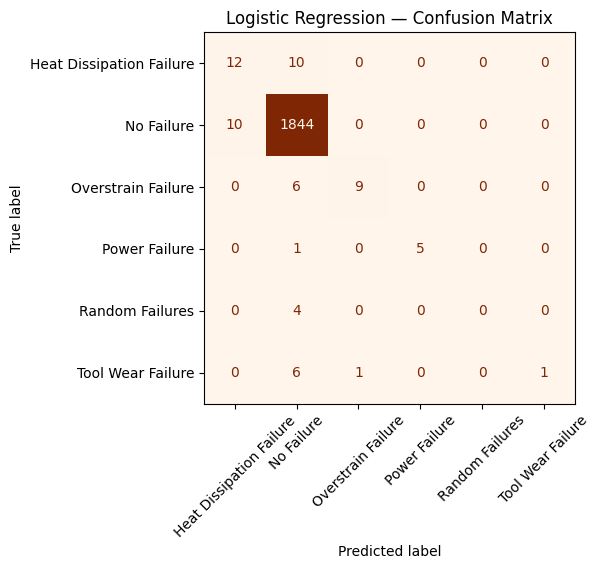


Logistic Regression
-------------------
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.55      0.55      0.55        22
              No Failure       0.99      0.99      0.99      1854
      Overstrain Failure       0.90      0.60      0.72        15
           Power Failure       1.00      0.83      0.91         6
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       1.00      0.12      0.22         8

                accuracy                           0.98      1909
               macro avg       0.74      0.52      0.56      1909
            weighted avg       0.98      0.98      0.98      1909



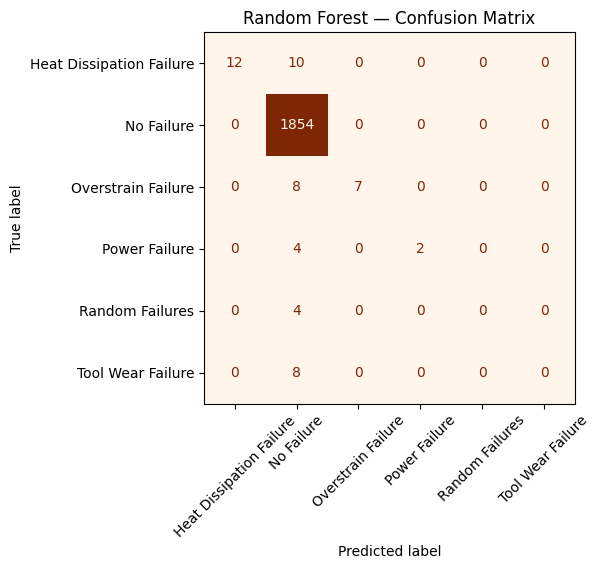


Random Forest
-------------
                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      0.55      0.71        22
              No Failure       0.98      1.00      0.99      1854
      Overstrain Failure       1.00      0.47      0.64        15
           Power Failure       1.00      0.33      0.50         6
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         8

                accuracy                           0.98      1909
               macro avg       0.66      0.39      0.47      1909
            weighted avg       0.98      0.98      0.98      1909



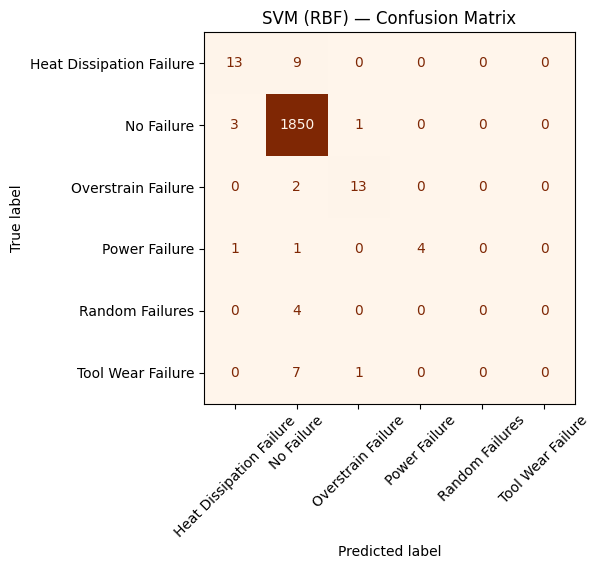


SVM (RBF)
---------
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.76      0.59      0.67        22
              No Failure       0.99      1.00      0.99      1854
      Overstrain Failure       0.87      0.87      0.87        15
           Power Failure       1.00      0.67      0.80         6
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         8

                accuracy                           0.98      1909
               macro avg       0.60      0.52      0.55      1909
            weighted avg       0.98      0.98      0.98      1909



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


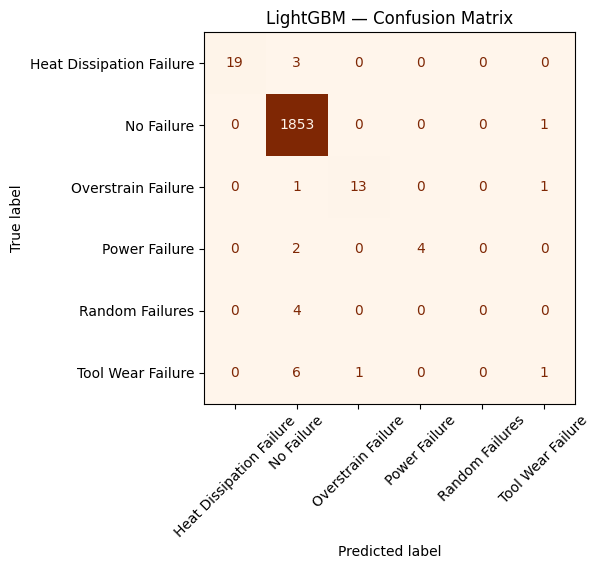


LightGBM
--------
                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      0.86      0.93        22
              No Failure       0.99      1.00      1.00      1854
      Overstrain Failure       0.93      0.87      0.90        15
           Power Failure       1.00      0.67      0.80         6
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.33      0.12      0.18         8

                accuracy                           0.99      1909
               macro avg       0.71      0.59      0.63      1909
            weighted avg       0.99      0.99      0.99      1909



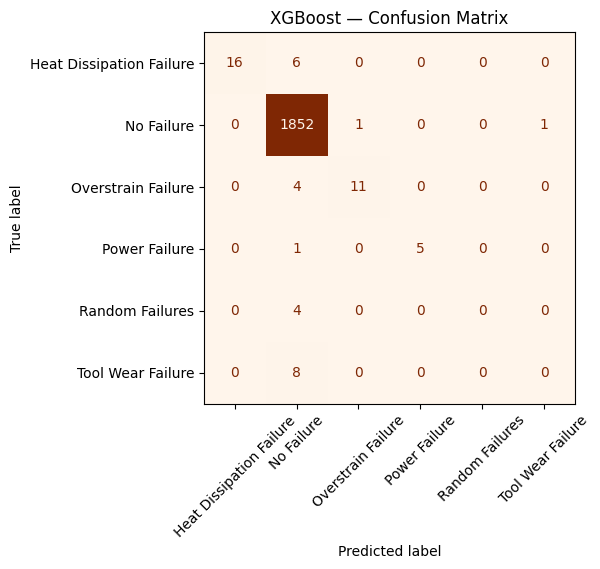


XGBoost
-------
                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      0.73      0.84        22
              No Failure       0.99      1.00      0.99      1854
      Overstrain Failure       0.92      0.73      0.81        15
           Power Failure       1.00      0.83      0.91         6
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         8

                accuracy                           0.99      1909
               macro avg       0.65      0.55      0.59      1909
            weighted avg       0.98      0.99      0.98      1909



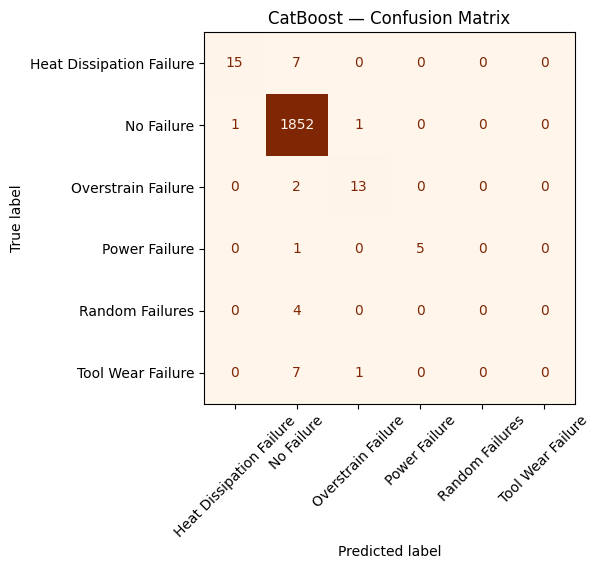


CatBoost
--------
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.94      0.68      0.79        22
              No Failure       0.99      1.00      0.99      1854
      Overstrain Failure       0.87      0.87      0.87        15
           Power Failure       1.00      0.83      0.91         6
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         8

                accuracy                           0.99      1909
               macro avg       0.63      0.56      0.59      1909
            weighted avg       0.98      0.99      0.98      1909



In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

all_pipes = {**tuned_nonensemble, **tuned_ensemble}

for name, pipe in all_pipes.items():
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, xticks_rotation=45, cmap="Oranges", colorbar=False)
    ax.set_title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n{name}\n" + "-" * len(name))
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

In [20]:
from sklearn.metrics import roc_auc_score

auc_results = []
for name, pipe in all_pipes.items():
    y_proba = pipe.predict_proba(X_test)
    auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
    auc_results.append({"Model": name, "AUC (weighted OvR)": auc})

pd.DataFrame(auc_results).sort_values("AUC (weighted OvR)", ascending=False)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,AUC (weighted OvR)
2,SVM (RBF),0.964859
0,Logistic Regression,0.963156
3,LightGBM,0.955163
5,CatBoost,0.942262
1,Random Forest,0.927963
4,XGBoost,0.922772


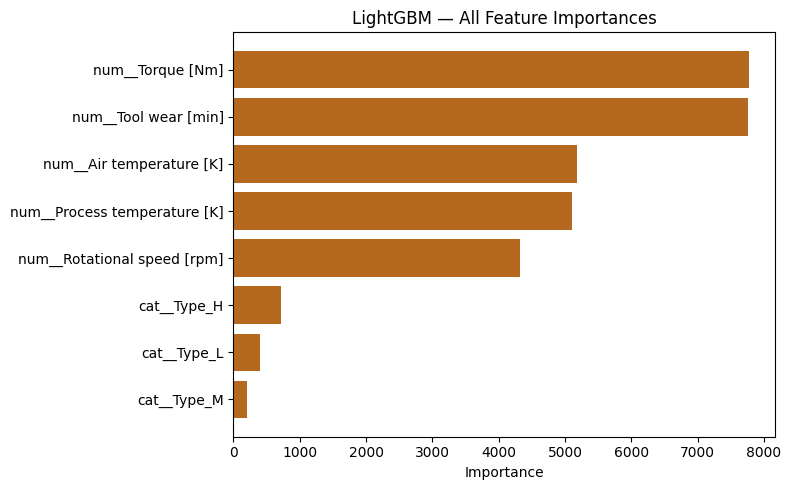

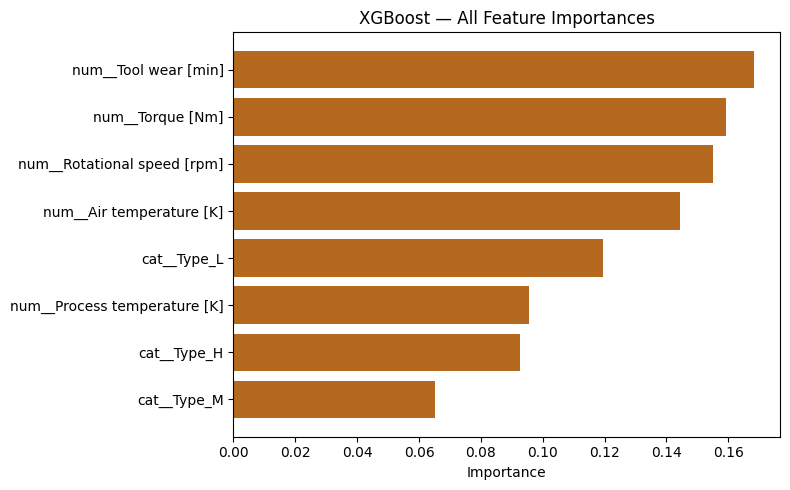

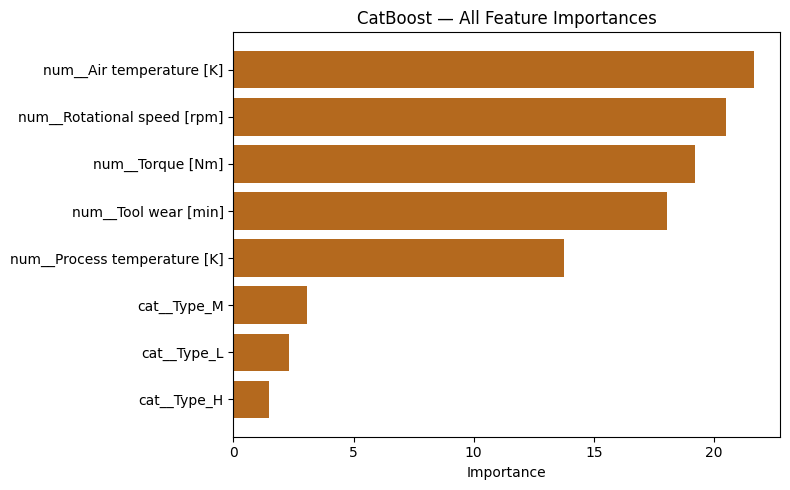

In [21]:
def plot_feature_importance(pipe, name):
    model = pipe.named_steps["model"]
    prep = pipe.named_steps["prep"]
    feat_names = prep.get_feature_names_out()
    importances = model.feature_importances_
    order = np.argsort(importances)

    plt.figure(figsize=(8, 5))
    plt.barh(feat_names[order], importances[order], color="#B4691E")
    plt.title(f"{name} — All Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

for name in ["LightGBM", "XGBoost", "CatBoost"]:
    plot_feature_importance(tuned_ensemble[name], name)

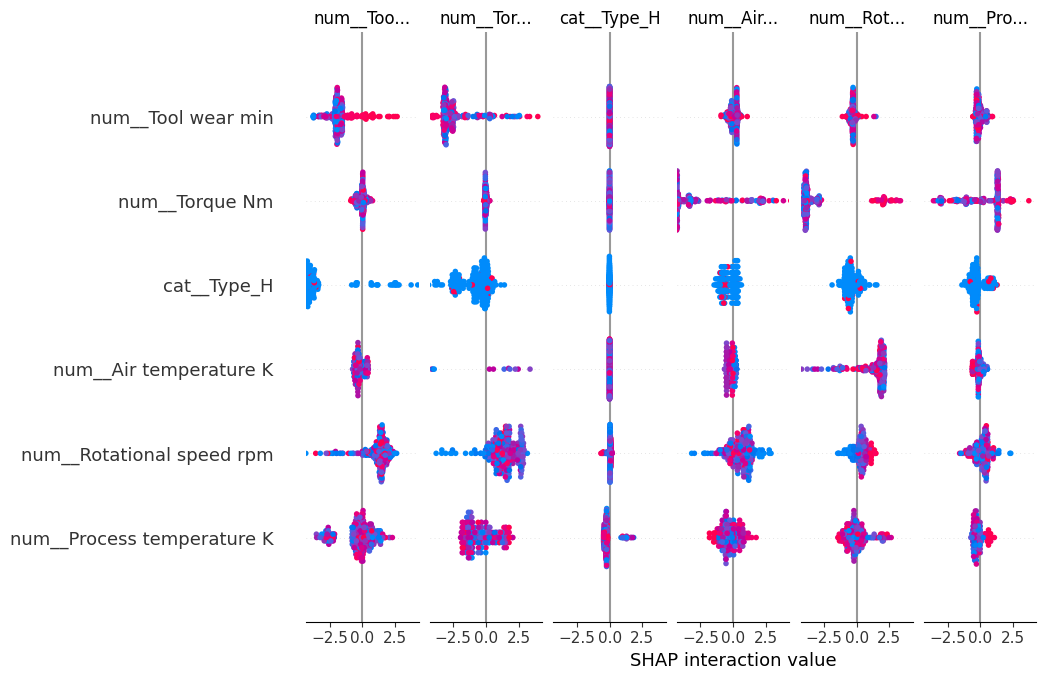

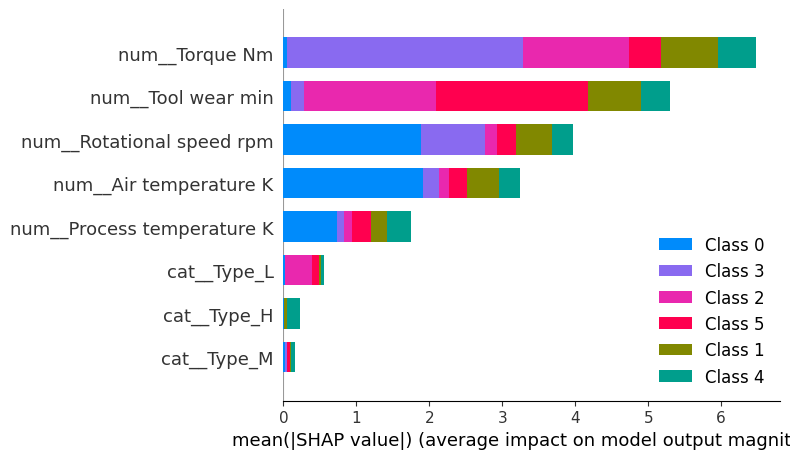

In [22]:
import shap

best_model_name = "XGBoost"   # swap for whichever model wins on your rerun
best_pipe = all_pipes[best_model_name]

TEST_N = min(300, len(X_test))
X_te = X_test.sample(TEST_N, random_state=42)

prep = best_pipe.named_steps["prep"]
model = best_pipe.named_steps["model"]

X_te_t = prep.transform(X_te)
if hasattr(X_te_t, "toarray"):
    X_te_t = X_te_t.toarray()

feat_names = prep.get_feature_names_out()
feat_names = [f.replace("[", "").replace("]", "").replace("<", "_") for f in feat_names]
X_te_df = pd.DataFrame(X_te_t, columns=feat_names)

explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(X_te_df)

shap.summary_plot(shap_vals, X_te_df, show=True)
shap.summary_plot(shap_vals, X_te_df, plot_type="bar", show=True)

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

X_cluster = preprocessor.fit_transform(X)

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

sil = silhouette_score(X_cluster, clusters)
ari = adjusted_rand_score(y, clusters)
print(f"Silhouette score (K-Means): {sil:.4f}")
print(f"Adjusted Rand Index (clusters vs true labels): {ari:.4f}")

pd.crosstab(clusters, df["Failure Type"], rownames=["Cluster ID"])

Silhouette score (K-Means): 0.1862
Adjusted Rand Index (clusters vs true labels): 0.0005


Failure Type,Heat Dissipation Failure,No Failure,Overstrain Failure,Power Failure,Random Failures,Tool Wear Failure
Cluster ID,,,,,,
0,64,1450,46,13,5,18
1,45,1617,0,2,6,0
2,0,1489,30,3,4,13
3,0,1573,0,0,2,1
4,2,1601,0,12,0,0
5,0,1535,0,0,1,9
